<a href="https://colab.research.google.com/github/Varsh555/ML2_lab/blob/main/ml2p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']

Train-Test Split
----------------
Training samples: 60
Testing samples: 90

Model training completed.
Predictions completed.


MODEL EVALUATION
Accuracy  : 0.9000
Precision : 0.9134
Recall    : 0.9000
F1-Score  : 0.8986

Classification Report
---------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
  versicolor       0.78      0.97      0.87        30
   virginica       0.96      0.73      0.83        30

    accuracy                           0.90        90
   macro avg       0.91      0.90      0.90        90
weighted avg       0.91      0.90      0.90        90


Confusion Matrix
----------------
[[30  0  0]
 [ 0 29  1]
 [ 0  8 22]]


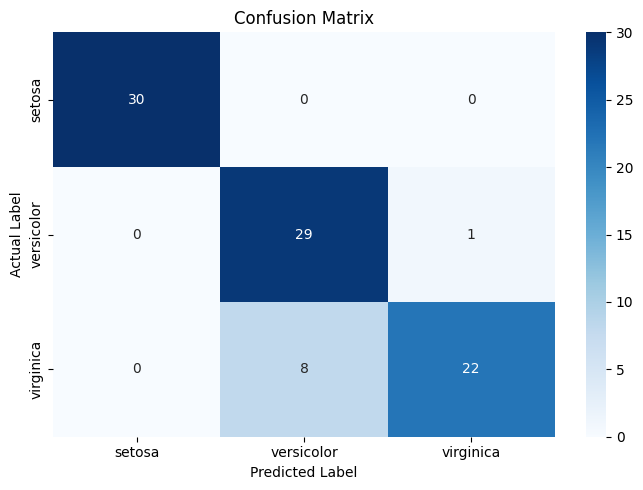

In [1]:
# ============================================================
# BASIC SUPERVISED LEARNING PIPELINE
# ============================================================

# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)


# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.60,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split")
print("----------------")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 3. CREATE CLASSIFIER
# ============================================================

classifier = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 4. TRAIN THE CLASSIFIER
# ============================================================

classifier.fit(
    X_train,
    y_train
)

print("\nModel training completed.")


# ============================================================
# 5. MAKE PREDICTIONS
# ============================================================

y_pred = classifier.predict(
    X_test
)

print("Predictions completed.")


# ============================================================
# 6. CALCULATE EVALUATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")
print("----------------")

print(cm)


# ============================================================
# 10. VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()